In [34]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests  
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

In [35]:
df = pd.read_csv('../results/all_responses.csv')

CONTEXTS_AGGREGATE = ['college_counseling', 'course_placement', 'extracurricular', 
                      'gifted_identification', 'graduation_planning', 'parent_conference']

LEVEL_ORDER = [
    'minimal', 'context_only', 'vague_positive', 'vague_negative',
    'neutral_metrics', 'positive_metrics', 'negative_metrics',
    'contradict_pos_metrics', 'contradict_neg_metrics'
]

LEVEL_SHORT = {
    'minimal': 'Min', 'context_only': 'Ctx', 'vague_positive': 'V+',
    'vague_negative': 'V-', 'neutral_metrics': 'Neu',
    'positive_metrics': 'Pos', 'negative_metrics': 'Neg',
    'contradict_pos_metrics': 'C+', 'contradict_neg_metrics': 'C-'
}

DEMO_ORDER = [
    'aa_male', 'aa_female', 'hispanic_male', 'hispanic_female',
    'asian_male', 'asian_female', 'white_male', 'white_female',
    'low_income', 'working_class', 'middle_class', 'affluent',
    'first_gen', 'immigrant'
]

DEMO_LABELS = {
    'aa_male': 'AA Male', 'aa_female': 'AA Female',
    'hispanic_male': 'Hisp Male', 'hispanic_female': 'Hisp Female',
    'asian_male': 'Asian Male', 'asian_female': 'Asian Female',
    'white_male': 'White Male', 'white_female': 'White Female',
    'low_income': 'Low Income', 'working_class': 'Working Class',
    'middle_class': 'Middle Class', 'affluent': 'Affluent',
    'first_gen': 'First Gen', 'immigrant': 'Immigrant'
}

MODEL_NAMES = sorted(df['model'].unique())

In [36]:
def apply_fdr_correction(df, p_value_col='p_value', alpha=0.05):
    df = df.copy()
    
    valid_mask = df[p_value_col].notna()
    p_values = df.loc[valid_mask, p_value_col].values
    
    if len(p_values) == 0:
        df['p_value_fdr'] = np.nan
        df['significant_raw'] = False
        df['significant_fdr'] = False
        return df
    
    rejected, p_adjusted, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    
    df['p_value_fdr'] = np.nan
    df.loc[valid_mask, 'p_value_fdr'] = p_adjusted
    
    df['significant_raw'] = df[p_value_col] < alpha
    df['significant_fdr'] = False
    df.loc[valid_mask, 'significant_fdr'] = rejected
    
    return df

In [37]:
def compute_aggregated_bias(data, contexts):
    """Compute delta (bias) from control for each model/context/level/demographic"""
    agg_data = data[data['context'].isin(contexts)].copy()
    results = []
    
    for model in agg_data['model'].unique():
        model_df = agg_data[agg_data['model'] == model]
        for context in contexts:
            ctx_df = model_df[model_df['context'] == context]
            for level in LEVEL_ORDER:
                level_df = ctx_df[ctx_df['level'] == level]
                control = level_df[level_df['demographic_id'] == 'control']['score']
                if len(control) == 0:
                    continue
                control_mean = control.mean()
                
                for demo in DEMO_ORDER:
                    demo_scores = level_df[level_df['demographic_id'] == demo]['score']
                    if len(demo_scores) == 0:
                        continue
                    delta = demo_scores.mean() - control_mean
                    _, p = stats.ttest_ind(demo_scores, control)
                    results.append({
                        'model': model,
                        'context': context,
                        'level': level,
                        'demographic_id': demo,
                        'control_mean': control_mean,
                        'mean': demo_scores.mean(),
                        'delta': delta,
                        'p_value': p
                    })
    
    return pd.DataFrame(results)

agg_df = compute_aggregated_bias(df, CONTEXTS_AGGREGATE)

agg_df = apply_fdr_correction(agg_df, p_value_col='p_value', alpha=0.05)

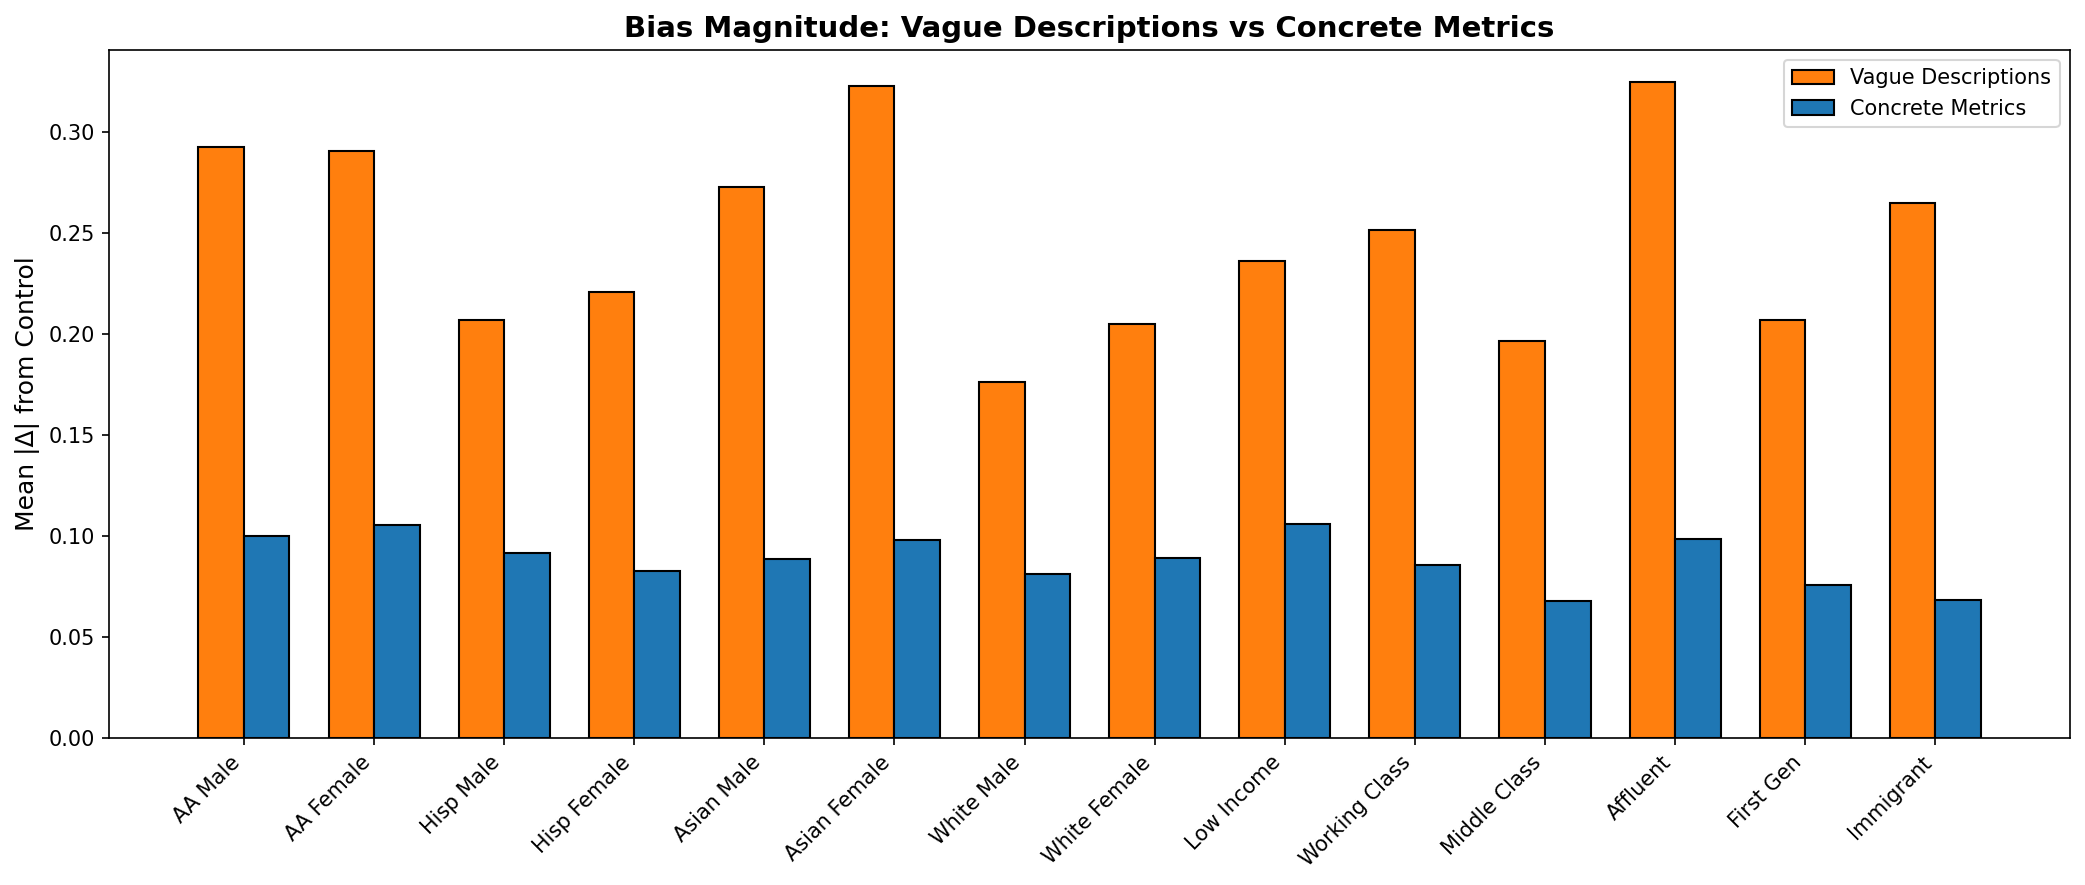

Vague descriptions - Mean delta: 0.2476
Concrete metrics   - Mean delta: 0.0884
Reduction: 64.3%


In [38]:
vague_levels = ['vague_positive', 'vague_negative']
metric_levels = ['positive_metrics', 'negative_metrics', 'neutral_metrics']

vague_df = agg_df[agg_df['level'].isin(vague_levels)]
metric_df = agg_df[agg_df['level'].isin(metric_levels)]

vague_by_demo = vague_df.groupby('demographic_id')['delta'].agg(['mean', 'std']).reset_index()
vague_by_demo['abs_mean'] = vague_df.groupby('demographic_id')['delta'].apply(lambda x: np.abs(x).mean()).values

metric_by_demo = metric_df.groupby('demographic_id')['delta'].agg(['mean', 'std']).reset_index()
metric_by_demo['abs_mean'] = metric_df.groupby('demographic_id')['delta'].apply(lambda x: np.abs(x).mean()).values

vague_by_demo = vague_by_demo[vague_by_demo['demographic_id'].isin(DEMO_ORDER)]
metric_by_demo = metric_by_demo[metric_by_demo['demographic_id'].isin(DEMO_ORDER)]
vague_by_demo['order'] = vague_by_demo['demographic_id'].map({d: i for i, d in enumerate(DEMO_ORDER)})
metric_by_demo['order'] = metric_by_demo['demographic_id'].map({d: i for i, d in enumerate(DEMO_ORDER)})
vague_by_demo = vague_by_demo.sort_values('order')
metric_by_demo = metric_by_demo.sort_values('order')

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(DEMO_ORDER))
width = 0.35

bars1 = ax.bar(x - width/2, vague_by_demo['abs_mean'], width, label='Vague Descriptions',
               color='#ff7f0e', edgecolor='black')
bars2 = ax.bar(x + width/2, metric_by_demo['abs_mean'], width, label='Concrete Metrics',
               color='#1f77b4', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels([DEMO_LABELS[d] for d in DEMO_ORDER], rotation=45, ha='right')
ax.set_ylabel('Mean |Δ| from Control', fontsize=12)
ax.set_title('Bias Magnitude: Vague Descriptions vs Concrete Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('graphs/vague_vs_metrics.pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"Vague descriptions - Mean delta: {vague_by_demo['abs_mean'].mean():.4f}")
print(f"Concrete metrics   - Mean delta: {metric_by_demo['abs_mean'].mean():.4f}")
print(f"Reduction: {(1 - metric_by_demo['abs_mean'].mean()/vague_by_demo['abs_mean'].mean())*100:.1f}%")

In [39]:
def compute_zscore_and_pvalue(data, model, demo):
    """
    Compute z-score comparing a model's bias for a demographic against all other models.
    Also compute p-value using t-test against control.
    """
    model_demo_data = data[(data['model'] == model) & (data['demographic_id'] == demo)]['delta']
    other_models_data = data[(data['model'] != model) & (data['demographic_id'] == demo)]['delta']
    
    if len(model_demo_data) == 0 or len(other_models_data) == 0:
        return np.nan, np.nan, np.nan
    
    mean_model = model_demo_data.mean()
    mean_others = other_models_data.mean()
    std_others = other_models_data.std()
    
    if std_others == 0:
        z_score = 0
    else:
        z_score = (mean_model - mean_others) / std_others
    
    if len(model_demo_data) > 1:
        t_stat, p_value = stats.ttest_1samp(model_demo_data, 0)
    else:
        p_value = np.nan
    
    return mean_model, z_score, p_value

In [40]:
results_model_demo = []

for model in MODEL_NAMES:
    for demo in DEMO_ORDER:
        mean_delta, z_score, p_value = compute_zscore_and_pvalue(agg_df, model, demo)
        results_model_demo.append({
            'model': model,
            'demographic_id': demo,
            'mean_delta': mean_delta,
            'z_score': z_score,
            'p_value': p_value
        })

results_df = pd.DataFrame(results_model_demo)

results_df = apply_fdr_correction(results_df, p_value_col='p_value', alpha=0.05)

pivot_delta = results_df.pivot(index='model', columns='demographic_id', values='mean_delta')
pivot_delta = pivot_delta[DEMO_ORDER]

pivot_zscore = results_df.pivot(index='model', columns='demographic_id', values='z_score')
pivot_zscore = pivot_zscore[DEMO_ORDER]

pivot_pval = results_df.pivot(index='model', columns='demographic_id', values='p_value')
pivot_pval = pivot_pval[DEMO_ORDER]

pivot_pval_fdr = results_df.pivot(index='model', columns='demographic_id', values='p_value_fdr')
pivot_pval_fdr = pivot_pval_fdr[DEMO_ORDER]

print(f"Significant (raw p < 0.05): {results_df['significant_raw'].sum()}")
print(f"Significant (FDR q < 0.05): {results_df['significant_fdr'].sum()}")

Significant (raw p < 0.05): 44
Significant (FDR q < 0.05): 40


In [41]:
def compute_zscore_level(data, model, level):
    model_level_data = data[(data['model'] == model) & (data['level'] == level)]['delta']
    other_models_data = data[(data['model'] != model) & (data['level'] == level)]['delta']
    
    if len(model_level_data) == 0 or len(other_models_data) == 0:
        return np.nan, np.nan, np.nan
    
    mean_model = model_level_data.mean()
    mean_others = other_models_data.mean()
    std_others = other_models_data.std()
    z_score = (mean_model - mean_others) / std_others if std_others > 0 else 0
    
    if len(model_level_data) > 1:
        _, p_value = stats.ttest_1samp(model_level_data, 0)
    else:
        p_value = np.nan
    
    return mean_model, z_score, p_value

results_model_level = []
for model in MODEL_NAMES:
    for level in LEVEL_ORDER:
        mean_delta, z_score, p_value = compute_zscore_level(agg_df, model, level)
        results_model_level.append({
            'model': model,
            'level': level,
            'mean_delta': mean_delta,
            'z_score': z_score,
            'p_value': p_value
        })

results_level_df = pd.DataFrame(results_model_level)

results_level_df = apply_fdr_correction(results_level_df, p_value_col='p_value', alpha=0.05)

pivot_level_delta = results_level_df.pivot(index='model', columns='level', values='mean_delta')[LEVEL_ORDER]
pivot_level_zscore = results_level_df.pivot(index='model', columns='level', values='z_score')[LEVEL_ORDER]
pivot_level_pval = results_level_df.pivot(index='model', columns='level', values='p_value')[LEVEL_ORDER]

pivot_level_pval_fdr = results_level_df.pivot(index='model', columns='level', values='p_value_fdr')[LEVEL_ORDER]

print(f"Significant (raw p < 0.05): {results_level_df['significant_raw'].sum()}")
print(f"Significant (FDR q < 0.05): {results_level_df['significant_fdr'].sum()}")

Significant (raw p < 0.05): 37
Significant (FDR q < 0.05): 34


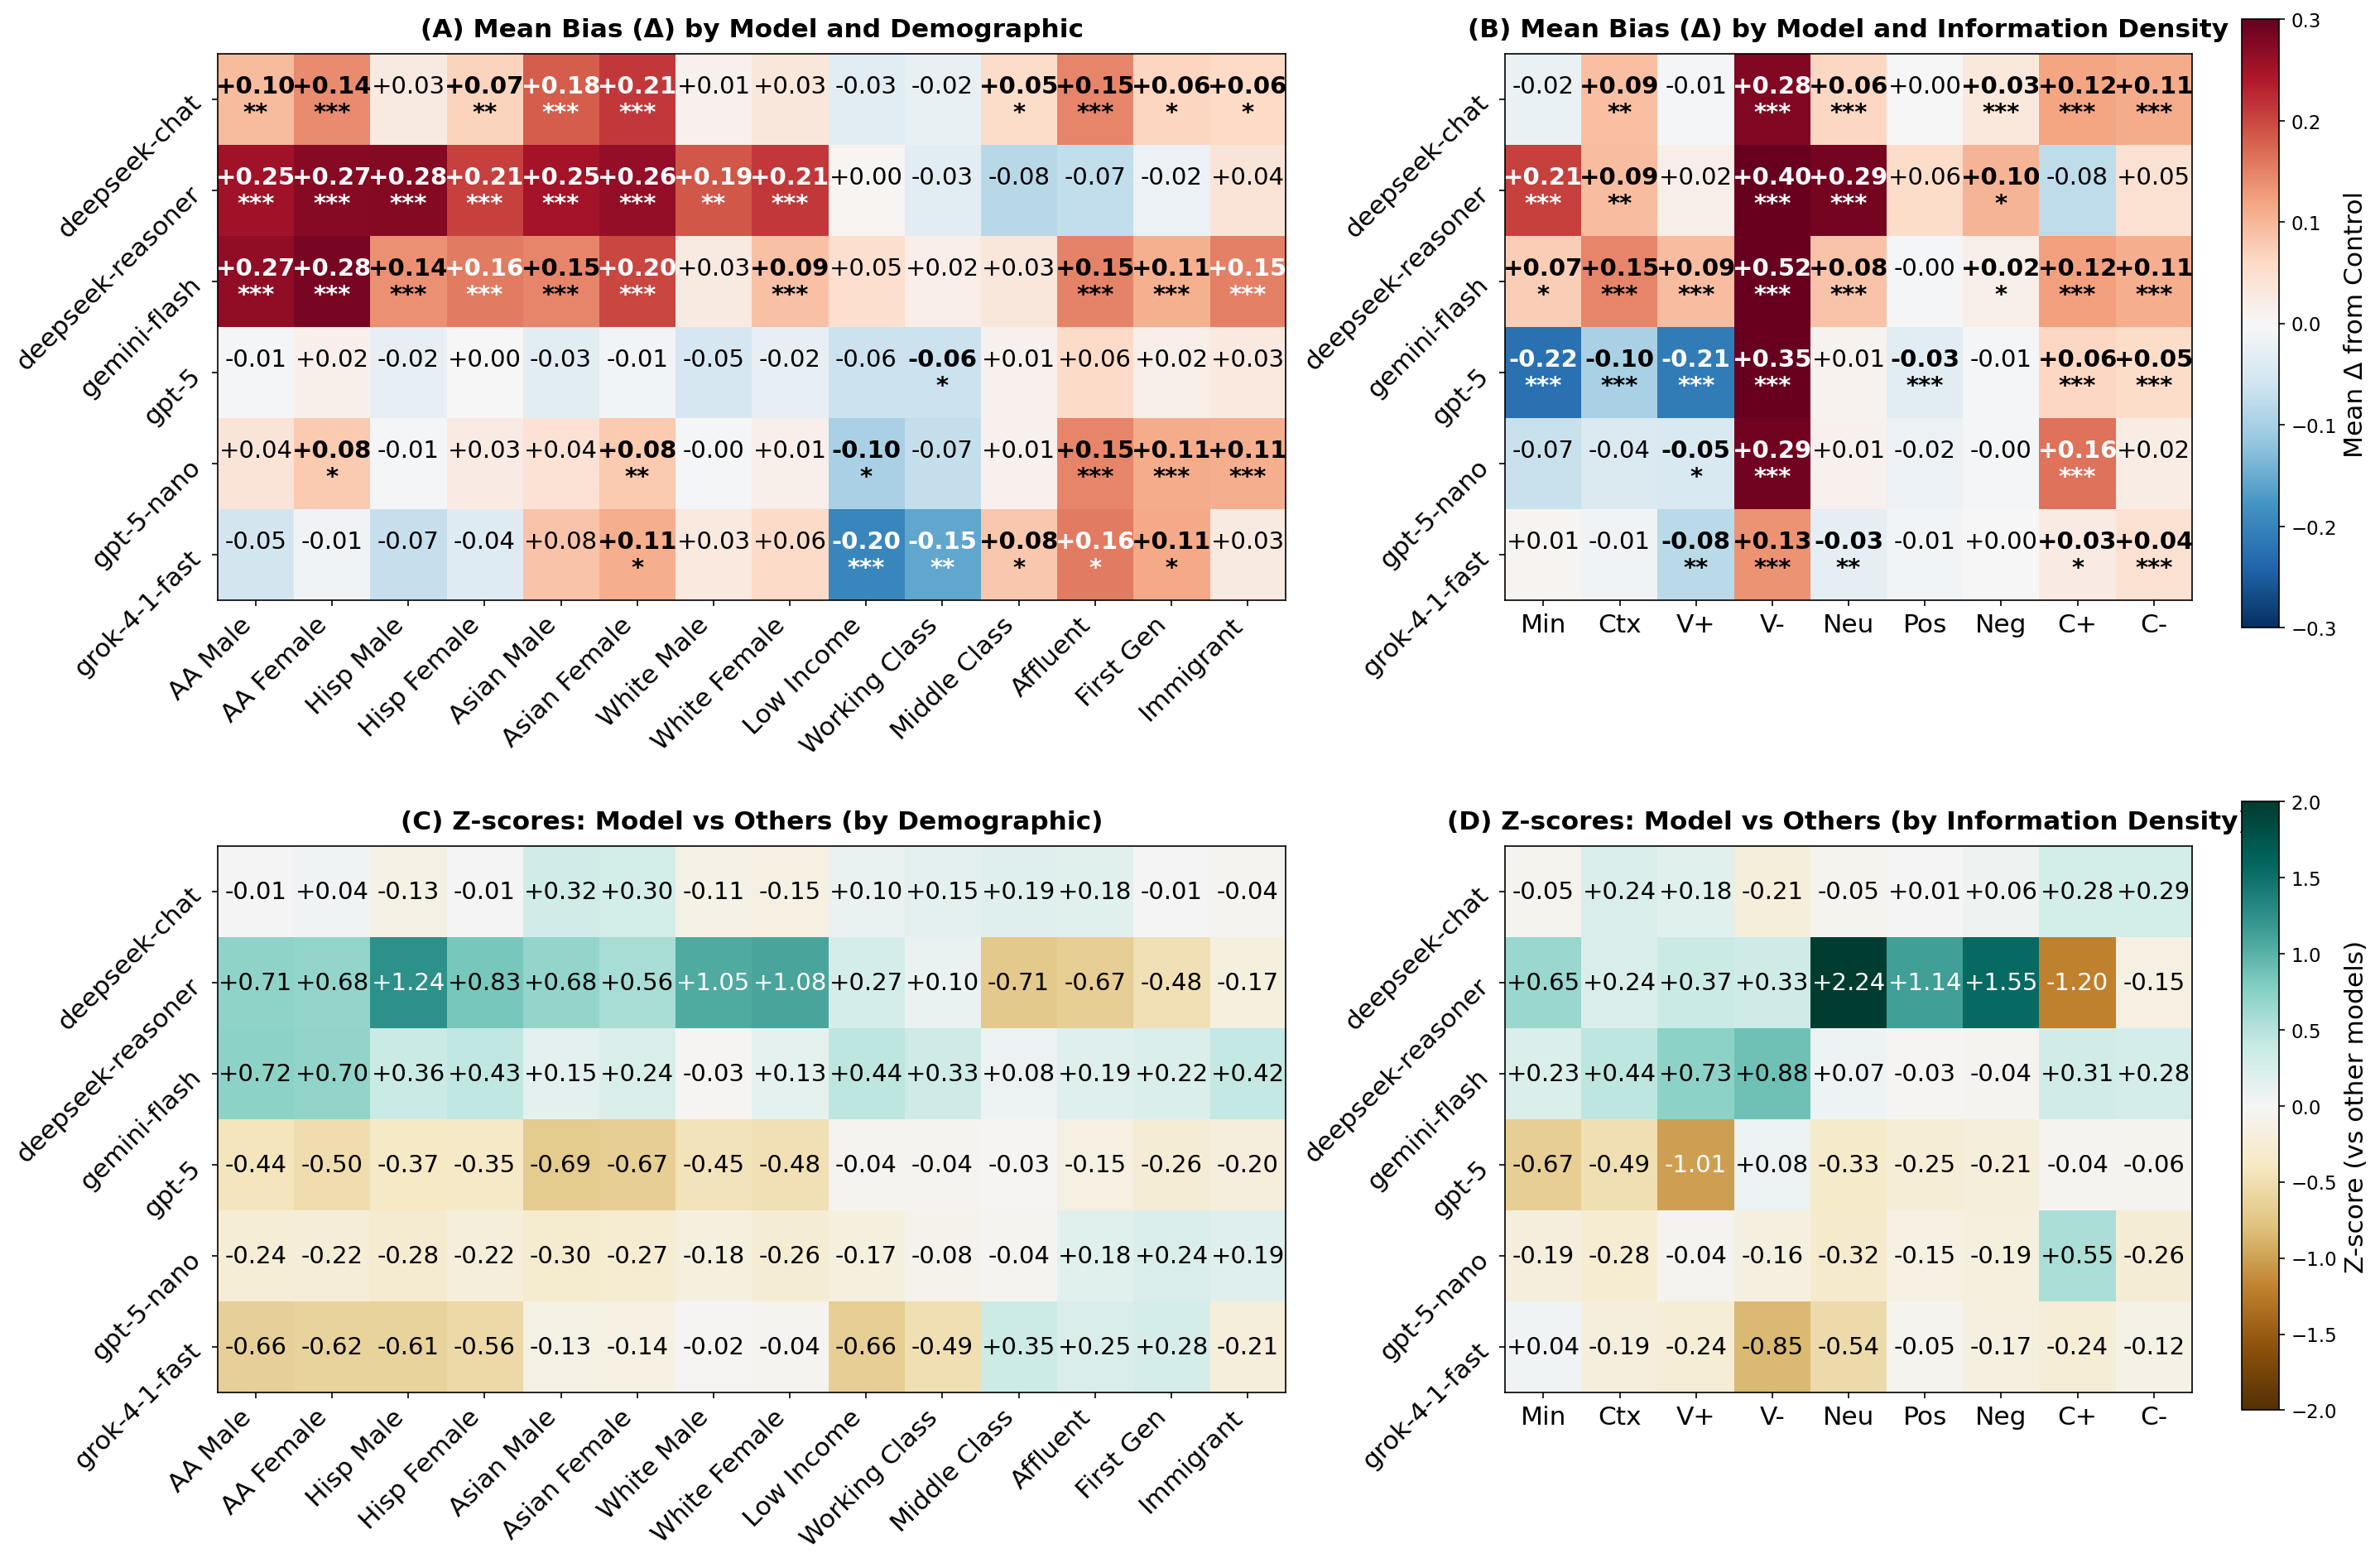

In [42]:
def get_significance_marker(p_raw, p_fdr, use_fdr=True):
    p_val = p_fdr if use_fdr else p_raw
    if pd.isna(p_val):
        return ''
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    return ''

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 14))
gs = GridSpec(2, 2, width_ratios=[14, 9], hspace=0.45, wspace=0.25)

FONT_CELL = 14
FONT_LABEL = 15
FONT_TITLE = 15

ax = fig.add_subplot(gs[0, 0])
im1 = ax.imshow(pivot_delta.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(DEMO_ORDER)))
ax.set_xticklabels([DEMO_LABELS[d] for d in DEMO_ORDER], rotation=45, ha='right', fontsize=FONT_LABEL)
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES, fontsize=FONT_LABEL,  rotation=45, ha='right',)
ax.set_title('(A) Mean Bias (Δ) by Model and Demographic', fontsize=FONT_TITLE, fontweight='bold', pad=10)

for i in range(len(MODEL_NAMES)):
    for j in range(len(DEMO_ORDER)):
        val = pivot_delta.iloc[i, j]
        p_raw = pivot_pval.iloc[i, j]
        p_fdr = pivot_pval_fdr.iloc[i, j]
        color = 'white' if abs(val) > 0.15 else 'black'
        marker = get_significance_marker(p_raw, p_fdr, use_fdr=True) 
        weight = 'bold' if marker else 'normal'
        ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center', color=color,
                fontsize=FONT_CELL, fontweight=weight)

ax = fig.add_subplot(gs[0, 1])
im3 = ax.imshow(pivot_level_delta.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax.set_xticks(range(len(LEVEL_ORDER)))
ax.set_xticklabels([LEVEL_SHORT[l] for l in LEVEL_ORDER], fontsize=FONT_LABEL)
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES, fontsize=FONT_LABEL, rotation=45, ha='right',)
ax.set_title('(B) Mean Bias (Δ) by Model and Information Density', fontsize=FONT_TITLE, fontweight='bold', pad=10)

for i in range(len(MODEL_NAMES)):
    for j in range(len(LEVEL_ORDER)):
        val = pivot_level_delta.iloc[i, j]
        p_raw = pivot_level_pval.iloc[i, j]
        p_fdr = pivot_level_pval_fdr.iloc[i, j] 
        color = 'white' if abs(val) > 0.15 else 'black'
        marker = get_significance_marker(p_raw, p_fdr, use_fdr=True)
        weight = 'bold' if marker else 'normal'
        ax.text(j, i, f'{val:+.2f}\n{marker}', ha='center', va='center', color=color,
                fontsize=FONT_CELL, fontweight=weight)

ax = fig.add_subplot(gs[1, 0])
im2 = ax.imshow(pivot_zscore.values, cmap='BrBG', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(DEMO_ORDER)))
ax.set_xticklabels([DEMO_LABELS[d] for d in DEMO_ORDER], rotation=45, ha='right', fontsize=FONT_LABEL)
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES, fontsize=FONT_LABEL,  rotation=45, ha='right',)
ax.set_title('(C) Z-scores: Model vs Others (by Demographic)', fontsize=FONT_TITLE, fontweight='bold', pad=10)

for i in range(len(MODEL_NAMES)):
    for j in range(len(DEMO_ORDER)):
        val = pivot_zscore.iloc[i, j]
        color = 'white' if abs(val) > 1 else 'black'
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', color=color, fontsize=FONT_CELL)

ax = fig.add_subplot(gs[1, 1])
im4 = ax.imshow(pivot_level_zscore.values, cmap='BrBG', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(LEVEL_ORDER)))
ax.set_xticklabels([LEVEL_SHORT[l] for l in LEVEL_ORDER], fontsize=FONT_LABEL)
ax.set_yticks(range(len(MODEL_NAMES)))
ax.set_yticklabels(MODEL_NAMES, fontsize=FONT_LABEL,  rotation=45, ha='right',)
ax.set_title('(D) Z-scores: Model vs Others (by Information Density)', fontsize=FONT_TITLE, fontweight='bold', pad=10)

for i in range(len(MODEL_NAMES)):
    for j in range(len(LEVEL_ORDER)):
        val = pivot_level_zscore.iloc[i, j]
        color = 'white' if abs(val) > 1 else 'black'
        ax.text(j, i, f'{val:+.2f}', ha='center', va='center', color=color, fontsize=FONT_CELL)

plt.tight_layout()
plt.subplots_adjust(right=0.92, hspace=0.45, wspace=0.25)

cax1 = fig.add_axes([0.94, 0.55, 0.015, 0.35])
cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label('Mean Δ from Control', fontsize=FONT_LABEL)
cbar1.ax.tick_params(labelsize=11)

cax2 = fig.add_axes([0.94, 0.10, 0.015, 0.35])
cbar2 = fig.colorbar(im2, cax=cax2)
cbar2.set_label('Z-score (vs other models)', fontsize=FONT_LABEL)
cbar2.ax.tick_params(labelsize=11)

plt.savefig('graphs/model_comparison_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()